# Virtualize a few example datasets

1. Grab URLS from CEDA test catalog
2. Virtualize them to OSN bucket
3. Verify that snippet to download them works

In [1]:
import httpx
import icechunk as ic
import xarray as xr
from cmip7_virtualization.virtualize import virtualize_from_urls
from cmip7_virtualization.storage import osn_storage, http_vccs_from_registry
from cmip7_virtualization.catalog import urls_from_stac_item
from cmip7_virtualization.store import repo_exists

In [2]:
BUCKET = 'leap-pangeo-pipeline'
ROOT_PREFIX = 'cmip7-virtualization/icechunk-v2'
CEDA_STAC  = "https://api.stac.esgf.ceda.ac.uk"
COLLECTION = "CMIP6"
N_ITEMS = 2

In [3]:
import subprocess

def op_read(ref):
    return subprocess.check_output(["op", "read", ref]).decode().strip()

key    = op_read("op://Work/z6baienaiyhiexztlbbonbeaka/Read-Write/Access_Key")
secret = op_read("op://Work/z6baienaiyhiexztlbbonbeaka/Read-Write/Secret_Access_Key")

In [4]:
r = httpx.get(f"{CEDA_STAC}/collections/{COLLECTION}/items?limit={N_ITEMS}", timeout=30)
r.raise_for_status()
all_items = r.json()["features"]

In [5]:
written_item_dict = {}
for item in all_items:
    
    cmip_id = item.get('id', False)
    assert cmip_id

    print(f"Creating icechunk storage")
    prefix = f"{ROOT_PREFIX}/{cmip_id}/"
    storage = osn_storage(
        bucket=BUCKET,
        prefix=prefix,
        access_key_id=key,
        secret_access_key=secret
        )
    written_item_dict[cmip_id] = storage
    
    # skip if repo already exists: (for now skip, since the ref building is slow, we can later think about updates?)
    if repo_exists(storage):
        print(f"skipping {prefix=} — already exists")
        continue    
    
    # Build references
    print(f"Building references")
    urls = urls_from_stac_item(item)
    print(f"{urls=}")
    vds, registry = virtualize_from_urls(urls)

    print(f"Setup repo")
    vccs = http_vccs_from_registry(registry=registry)
    config = ic.RepositoryConfig.default()
    for vcc in vccs:
        config.set_virtual_chunk_container(vcc)
    repo = ic.Repository.open_or_create(
        storage=storage,
        config=config
    )
    
    print(f"Write to icechunk \n {prefix=}")
    session = repo.writable_session('main')
    vds.vz.to_icechunk(session.store)
    snapshot_id = session.commit("cmip")
    repo.save_config()
    print(snapshot_id)

Creating icechunk storage
skipping prefix='cmip7-virtualization/icechunk-v2/CMIP6.ScenarioMIP.MOHC.UKESM1-0-LL.ssp585.r1i1p1f2.AERday.zg500.gn.v20190726/' — already exists
Creating icechunk storage
skipping prefix='cmip7-virtualization/icechunk-v2/CMIP6.ScenarioMIP.MOHC.UKESM1-0-LL.ssp585.r1i1p1f2.AERday.zg1000.gn.v20210611/' — already exists


# snippet to download the data locally (new version -- icechunk v2)
You can download the icechunk stores locally using the AWS CLI

```
aws s3 cp s3://leap-pangeo-pipeline/cmip7-virtualization/icechunk-v2/<prefix>/ \
  ./local-icechunk/ \
  --recursive \
  --no-sign-request \
  --endpoint-url https://nyu1.osn.mghpcc.org
```
with any of the above prefixes, for example:

```
aws s3 cp s3://leap-pangeo-pipeline/cmip7-virtualization/icechunk-v2/CMIP6.ScenarioMIP.MOHC.UKESM1-0-LL.ssp585.r1i1p1f2.AERday.zg100.gn.v20210611/ \
  ./local-icechunk/ \
  --recursive \
  --no-sign-request \
  --endpoint-url https://nyu1.osn.mghpcc.org
```

<details>
    <summary>Old location</summary>

# snippet to download the data locally (old version -- icechunk v1)
You can download the icechunk stores locally using the AWS CLI

```
aws s3 cp s3://leap-pangeo-pipeline/cmip7-virtualization/<prefix>/ \
  ./local-icechunk/ \
  --recursive \
  --no-sign-request \
  --endpoint-url https://nyu1.osn.mghpcc.org
```
with any of the above prefixes, for example:

```
aws s3 cp s3://leap-pangeo-pipeline/cmip7-virtualization/CMIP6.VolMIP.NERC.UKESM1-0-LL.volc-pinatubo-full.r9i1p1f2.day.zg.gn.v20230810/ \
  ./local-icechunk/ \
  --recursive \
  --no-sign-request \
  --endpoint-url https://nyu1.osn.mghpcc.org
```

</details>

In [6]:
storage

<icechunk.Storage>
type: S3 (native)
bucket: leap-pangeo-pipeline
prefix: cmip7-virtualization/icechunk-v2/CMIP6.ScenarioMIP.MOHC.UKESM1-0-LL.ssp585.r1i1p1f2.AERday.zg1000.gn.v20210611
region: us-east-1
endpoint_url: https://nyu1.osn.mghpcc.org
force_path_style: True

In [9]:
# Test that we can read the data!
repo_read = ic.Repository.open(
    storage=storage,
    authorize_virtual_chunk_access={
        'https://dap.ceda.ac.uk/': ic.credentials.HttpAccess, # hardcoded for now, should be resolved dynamically
    }
)
session = repo_read.readonly_session('main')
ds = xr.open_zarr(session.store)

/Users/juliusbusecke/Code/cmip7-virtualization/.worktrees/parsing-performance/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:139: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


In [14]:
ds

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 30960, lat: 144, bnds: 2, lon: 192)
Coordinates:
  * time       (time) object 248kB 2015-01-01 12:00:00 ... 2100-12-30 12:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    plev       float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) float64 71MB dask.array<chunksize=(1, 144, 2), meta=np.ndarray>
    time_bnds  (time, bnds) object 495kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    zg1000     (time, lat, lon) float32 3GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 95MB dask.array<chunksize=(1, 192, 2), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   59400.0
    branch_time_in_parent:  59400.0
    creation_date:          2021-06-10T15:49:44Z
    ...                     ...
    tracking_id:            hdl:21.14100/807b3dc2-c390-4959-8d57-9ff24466b990
    variable_id:            zg1000
    variable_name:          zg1000
    variant_label:          r1i1p1f2
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.6.1

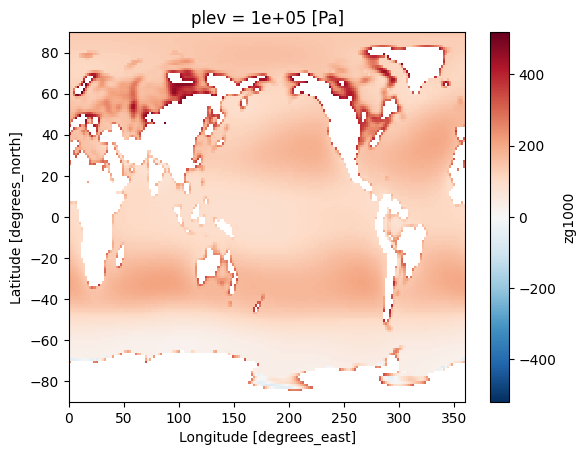

In [15]:
ds.zg1000.mean(['time']).plot()